# caife quickstart

A minimal, self-contained walk-through of `caife` on synthetic toy data.

In [1]:
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt

import caife

## Toy data

`create_data` draws a proxy `X`, a target `y`, sample weights `w`, and a systematic parameter `S`. This data is then split into a training and a testing set.

In [2]:
from caife import examples

(X_trn, y_trn, w_trn, S_trn), (X_tst, y_tst) = examples.split_data(
    *examples.create_data(rng=1491), rng=1491)

print(f"Shapes: X_trn {X_trn.shape}, X_tst {X_tst.shape} S_trn {S_trn.shape}")

Shapes: X_trn (100000, 1), X_tst (100000, 1) S_trn (100000, 1)


`caife` requires the `target_bins`, into which `y` will be discretized, to range from `-inf` to `inf`. The two outermost bins typically are overflow bins that catch everything outside the bins that are actually relevant to the analysis.

The `proxy_bins` should also range from `-inf` to `inf`. It is typically advisable to use more proxy bins than target bins.

In [3]:
target_bins = np.concatenate(([-np.inf], np.linspace(-4, 5, 10), [np.inf]))
proxy_bins = np.concatenate(([-np.inf], np.linspace(-6, 8, 15), [np.inf]))
print("target_bins:", target_bins)
print("proxy_bins:", proxy_bins)

target_bins: [-inf  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.  inf]
proxy_bins: [-inf  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.   6.
   7.   8.  inf]


With the target and proxy bins defined, we can set up a simple linear count model for the data. This model does not yet consider any systematic parameters `S_trn`.

In [4]:
model = caife.LinearCountModel(target_bins, caife.UnivariateBinning(proxy_bins))
model.fit(X_trn, y_trn, sample_weight=w_trn);

Using this model, we now inspect the target distribution `f(y)` in three variants:

- the unweighted training set
- the weighted training set
- the test set

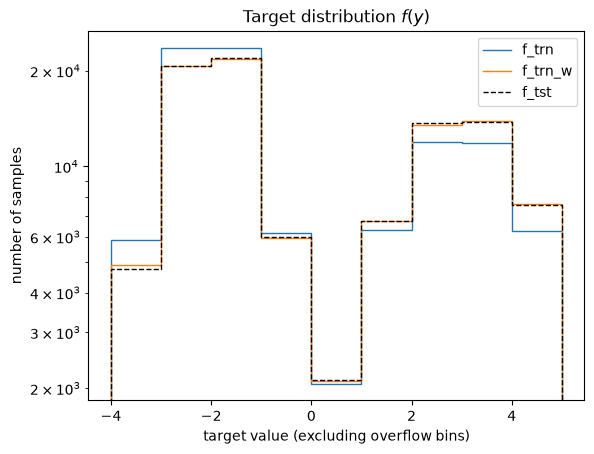

In [5]:
f_trn = model.target_view(y_trn)
f_trn_w = model.target_view(y_trn, sample_weight=w_trn)
f_tst = model.target_view(y_tst)

plt.stairs(f_trn[1:-1], edges=target_bins[1:-1], label="f_trn") # exclude over-flow bins
plt.stairs(f_trn_w[1:-1], edges=target_bins[1:-1], label="f_trn_w")
plt.stairs(f_tst [1:-1], edges=target_bins[1:-1], ls="--", color="black", label="f_tst")
plt.yscale("log")
plt.xlabel("target value (excluding overflow bins)")
plt.ylabel("number of samples")
plt.title("Target distribution $f(y)$")
plt.legend()
plt.show()

We also inspect the smeared proxy distribution `g(X)`.

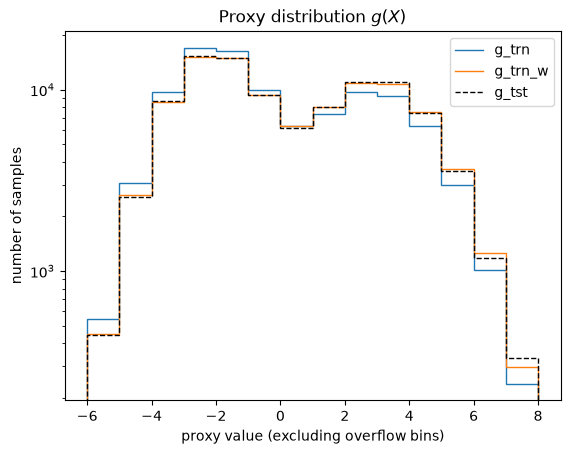

In [6]:
g_trn = model.proxy_view(X_trn)
g_trn_w = model.proxy_view(X_trn, sample_weight=w_trn)
g_tst = model.proxy_view(X_tst)

plt.stairs(g_trn[1:-1], edges=proxy_bins[1:-1], label="g_trn") # exclude over-flow bins
plt.stairs(g_trn_w[1:-1], edges=proxy_bins[1:-1], label="g_trn_w")
plt.stairs(g_tst [1:-1], edges=proxy_bins[1:-1], ls="--", color="black", label="g_tst")
plt.yscale("log")
plt.xlabel("proxy value (excluding overflow bins)")
plt.ylabel("number of samples")
plt.title("Proxy distribution $g(X)$")
plt.legend()
plt.show()

## Effective areas

Real detectors rarely observe a quantity's true flux directly: geometric acceptance, trigger thresholds, and target-dependent efficiencies all reshape the true distribution into whatever ends up being recorded. An **effective area** `a_eff` quantifies this instrument-specific distortion, so that dividing the observed counts `f` by `a_eff` recovers the physical flux `f / a_eff`. It is typically this flux that is of scientific interest, and that, unlike raw counts, does not depend on the particularities of the experiment.

`examples.create_effective_areas` provides an `a_eff` vector for our toy target bins that is constructed specifically so that `log(f_true / a_eff)` is (log-)linear, mimicking how many physical flux spectra behave.

The correction with effective areas also matters methodologically, because further below we regularize the logarithm of the spectrum during unfolding, which implicitly favors solutions that vary smoothly, close to log-linearly, across bins. The raw target distribution `f(y)` that we plotted above has an irregular double-peak shape that does not fit this assumption at all; the flux `f(y) / a_eff`, in contrast, does, and can therefore be meaningfully regularized. From here on, we unfold and regularize the flux rather than the raw counts.

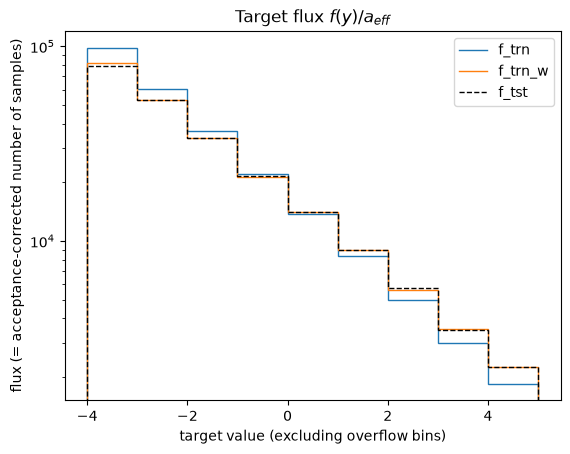

In [7]:
# retrieve the effective areas for the given target bins
a_eff = examples.create_effective_areas(target_bins)

# same plot as before, but with effective areas
plt.stairs(f_trn[1:-1] / a_eff, edges=target_bins[1:-1], label="f_trn")
plt.stairs(f_trn_w[1:-1] / a_eff, edges=target_bins[1:-1], label="f_trn_w")
plt.stairs(f_tst [1:-1] / a_eff, edges=target_bins[1:-1], ls="--", color="black", label="f_tst")
plt.yscale("log")
plt.xlabel("target value (excluding overflow bins)")
plt.ylabel("flux (= acceptance-corrected number of samples)")
plt.title("Target flux $f(y) / a_{eff}$")
plt.legend()
plt.show()

## Response matrix

The fitted model contains a **response matrix** `model.A_`, of shape `(n_proxy_bins, n_target_bins)`. In this matrix, the `t`-th column holds the proxy distribution that a sample from target bin `t` alone would produce. Unfolding means inverting the (ill-posed) linear system `g ≈ A @ f + background` to recover the un-observed target spectrum `f` from an observed proxy spectrum `g`.

We can visualize `model.A_` to see how strongly proxy bins mix across target bins. A perfectly sharp, non-smearing proxy would place all of its mass on the diagonal. Off-diagonal entries increase the difficulty of the unfolding task.

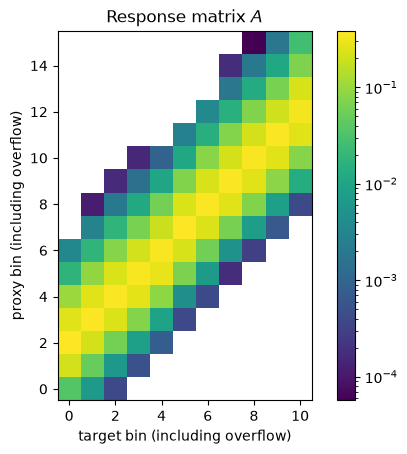

In [8]:
from matplotlib.colors import LogNorm

plt.imshow(model.A_, norm=LogNorm())
plt.gca().invert_yaxis()
plt.xlabel("target bin (including overflow)")
plt.ylabel("proxy bin (including overflow)")
plt.title("Response matrix $A$")
plt.colorbar()
plt.show()

## Setting up the likelihood

To recover `f` from the *observed* proxy spectrum `g_tst = model.proxy_view(X_tst)`, we minimize the negative log-likelihood of observing `g_tst` under a candidate spectrum `f`. Since `g_tst` holds counts, we use the Poisson likelihood implemented in `caife.poisson_nll`.

Directly inverting `A` tends to amplify noise, because the problem is ill-posed, as we just saw in the matrix above. We therefore add Tikhonov regularization on the logarithm of `f`, to smooth the estimate. The regularization strength is controlled by a hyperparameter `tau`: here, a smaller value of `tau` means *stronger* regularization, and the precise value needs to be tuned.

In [9]:
from jax import numpy as jnp # differentiable numpy wrapper

# inspect the structure of model parameters
print(model.create_latents(X_tst)) # -> just a single latent that directly represents the spectrum

# define the negative log-likelihood function from model parameters and optional hyper-parameters like tau
def nll(params, tau): # params=f, as we can see from model.create_latents(X_tst) above
    g_est = model(params) # apply the model to the parameters that are being fitted
    value = caife.poisson_nll(g_est, g_tst) # compute the negative log-likelihood loss
    value += caife.tikhonov_regularization( # add regularization to the logarithm of inner bins
        jnp.log(params[1:-1] / a_eff + 1e-10)) / tau
    return value

LatentSpectrum(n_samples=100000, n_bins_target=11)


Using this likelihood function, we instantiate a single `caife.ScipySolver` that we can reuse across multiple unfoldings. Reusing an existing solver can lead to substantial speed-ups because the solver can cache JIT-compiled functions and derivatives, instead of differentiating and compiling them more often than necessary.

In [10]:
solver = caife.ScipySolver(nll, model.create_latents(X_tst), seed=1491)

## Solving for the target spectrum

Our `solver` minimizes `nll` in a numerically favorable *latent* space that is controlled by `model.create_latents(X_tst)`. This latent space guarantees that every candidate solution is a valid, non-negative count spectrum that sums to `len(X_tst)`. Since this optimization is non-convex, the solver can restart from multiple random starting points: it starts at least `min_trials` trials (1 by default) and continues until at least `min_valid_trials` of them (1 by default) have produced a valid result, but it never starts more than `max_trials` trials (100 by default). It then returns the best *valid* result, that is, one whose Hessian confirms that it is indeed a local minimum, not a saddle point or divergent fit.

In [11]:
tau = 1.0 # for simplicity, just fix tau to some value; it will be tuned further below
f_est, aux = solver.solve(args=(tau,), return_aux=True) # also return auxiliary information on the fit

print("unfolded spectrum:", np.round(f_est[1:-1]).astype(int))
print("true spectrum:    ", np.round(f_tst[1:-1]).astype(int))

unfolded spectrum: [ 4565 21497 21508  5940  1781  6971 12340 16459  6033]
true spectrum:     [ 4742 20722 21880  6011  2120  6745 13705 13792  7559]


## Estimating uncertainties

`caife.uncertainty_from_aux` estimates the statistical uncertainty of the unfolded spectrum by sampling many candidate spectra around the found solution, using the local curvature of the likelihood. It reports their 16th and 84th percentiles, that is, the asymmetric 1-sigma error bars.

In [12]:
f_lower, f_upper = caife.uncertainty_from_aux(aux, rng=np.random.default_rng(1491))

print("lower 1-sigma errors:", np.round(f_est - f_lower)[1:-1].astype(int))
print("upper 1-sigma errors:", np.round(f_upper - f_est)[1:-1].astype(int))

lower 1-sigma errors: [ 743 1481 1582  818  410  788 1099 1123  654]
upper 1-sigma errors: [ 799 1379 1424  896  496  806 1043 1011  664]


## Comparing the unfolded result to the truth

Finally, we compare the unfolded spectrum to the *true* target distribution of the test set, `f_tst`. This ground truth is only available because we generated this data ourselves; in a real experiment, `f_tst` is exactly what unfolding tries to recover from the observed proxy data alone. The lower panel shows the ratio between the unfolded estimate and the truth, which should be close to one within the estimated uncertainties.

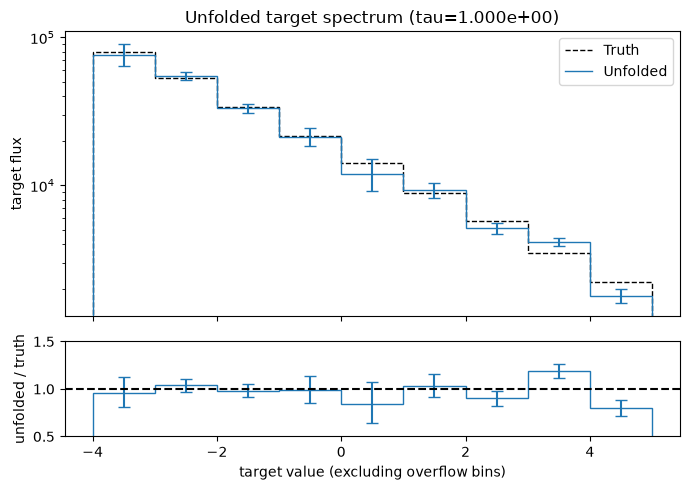

In [13]:
def plot_result(f_est, f_lower, f_upper, tau):
    target_bc = (target_bins[1:-2] + target_bins[2:-1]) / 2 # bin centers, excluding overflow bins
    
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    
    # upper panel: true and unfolded target fluxes
    ax1.stairs(f_tst[1:-1] / a_eff, edges=target_bins[1:-1], ls="dashed", color="black", label="Truth")
    ax1.stairs(f_est[1:-1] / a_eff, edges=target_bins[1:-1], color="C0", label="Unfolded")
    ax1.errorbar(
        target_bc, f_est[1:-1] / a_eff,
        yerr=np.stack((f_est[1:-1] - f_lower[1:-1], f_upper[1:-1] - f_est[1:-1])) / a_eff,
        color="C0", capsize=4, ls="",
    )
    ax1.set_yscale("log")
    ax1.set_ylabel("target flux")
    ax1.set_title(f"Unfolded target spectrum (tau={tau:.3e})")
    ax1.legend()
    
    # lower panel: unfolded spectrum divided by true spectrum (relative residuals)
    ax2.stairs(f_est[1:-1] / f_tst[1:-1], edges=target_bins[1:-1], color="C0")
    ax2.errorbar(
        target_bc, f_est[1:-1] / f_tst[1:-1],
        yerr=np.stack((f_est[1:-1] - f_lower[1:-1], f_upper[1:-1] - f_est[1:-1])) / f_tst[1:-1],
        color="C0", capsize=4, ls="",
    )
    ax2.axhline(1.0, color="black", ls="dashed")
    ax2.set_ylim((0.5, 1.5))
    ax2.set_xlabel("target value (excluding overflow bins)")
    ax2.set_ylabel("unfolded / truth")
    
    plt.tight_layout()
    plt.show()

plot_result(f_est, f_lower, f_upper, tau)

## Tuning the regularization strength

Above, we simply fixed `tau = 1.0`. In practice, `tau` needs to be tuned: too much regularization (small `tau`) oversmooths the spectrum and biases it away from the truth, while too little regularization (large `tau`) leaves the estimate exposed to the noise amplification of the ill-posed inversion.

To find a good `tau`, we solve the same unfolding problem for many candidate values and score each result with several criteria:

- `caife.gcc_from_aux` and `caife.pcs_from_aux` measure how strongly the estimated target bins correlate with each other. They derive these correlations from the auxiliary information `aux` of the solver, so that they characterize the parameters that the solver has actually fitted. Regularization ties neighboring bins together, so an over-regularized fit shows up as unusually high correlations, even without knowing the truth.
- The Hessian condition number (`aux["cond"]`) reflects how numerically stable the fit is; a poorly conditioned Hessian is a sign of an under-regularized, unstable fit.
- Since we generated this toy data ourselves, we can additionally compute the *true* relative error between the unfolded and the true spectrum, `rae`. This criterion is only available here because we know the ground truth `f_tst`; in a real analysis, you would rely on the first three, truth-free criteria instead.

In [14]:
import pandas as pd
from tqdm import tqdm

# consider many different tau values
results = []
tau_values = np.logspace(1, -5, 19)
for tau in tqdm(tau_values, ncols=80):

    # solve the unfolding task, just as above
    f_est, aux = solver.solve(args=(tau,), return_aux=True)

    if f_est is not None: # only proceed if a valid solution was found

        # estimate the uncertainties, just as above
        f_lower, f_upper = caife.uncertainty_from_aux(aux, rng=np.random.default_rng(1491))

        # assess the quality of the fit, according to several criteria
        gcc = caife.gcc_from_aux(aux)
        pcs = caife.pcs_from_aux(aux)
        cond = aux["cond"] # the condition number of the fit

        # also evaluate the true relative error, which is never available in practice
        rae = np.mean(np.abs(f_est[1:-1] - f_tst[1:-1]) / f_tst[1:-1])

        # store the results
        results.append({
            "tau": tau,
            "f_est": f_est,
            "f_lower": f_lower,
            "f_upper": f_upper,
            "gcc": gcc,
            "pcs": pcs,
            "cond": cond,
            "rae": rae,
            "aux": aux,
        })
results = pd.DataFrame(results)
print(f"Produced {len(results)}/{len(tau_values)} valid results") # invalid results are not stored

  0%|                                                    | 0/19 [00:00<?, ?it/s]

  5%|██▎                                         | 1/19 [00:05<01:40,  5.61s/it]

 11%|████▋                                       | 2/19 [00:10<01:27,  5.16s/it]

 16%|██████▉                                     | 3/19 [00:14<01:17,  4.85s/it]

 21%|█████████▎                                  | 4/19 [00:19<01:10,  4.69s/it]

...

 89%|██████████████████████████████████████▍    | 17/19 [01:17<00:08,  4.42s/it]

 95%|████████████████████████████████████████▋  | 18/19 [01:21<00:04,  4.42s/it]

100%|███████████████████████████████████████████| 19/19 [01:25<00:00,  4.41s/it]

100%|███████████████████████████████████████████| 19/19 [01:25<00:00,  4.52s/it]

Produced 19/19 valid results


We can now plot each of the the truth-free criteria against `tau` (colored points, left axes), together with the true relative error for reference (black points, right axes). The vertical line marks the `tau` that minimizes the respective criterion. If a criterion is a good proxy for the (otherwise unknown) true error, its minimum should roughly align with the minimum of the black `rae` points.

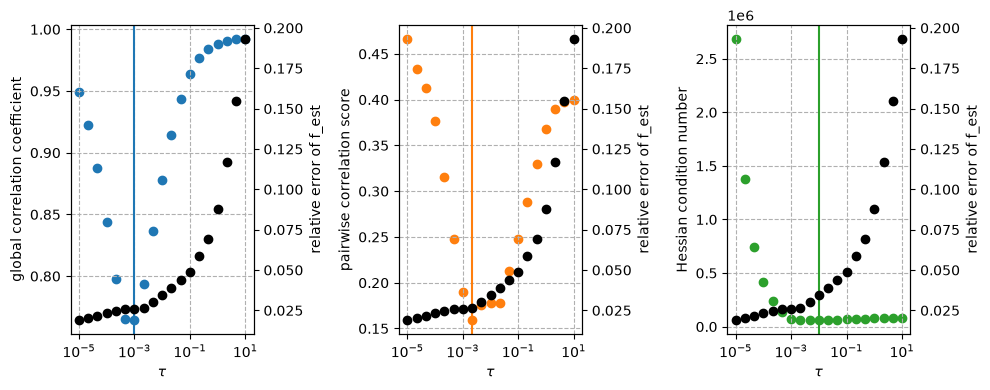

In [15]:
criteria = [ # pairs (name, column)
    ("global correlation coefficient", "gcc"),
    ("pairwise correlation score", "pcs"),
    ("Hessian condition number", "cond"),
]
fig, axs = plt.subplots(1, len(criteria), figsize=(10, 4)) # default figsize is (6.4, 4.8)

for i in range(len(criteria)):
    name_i, column_i = criteria[i]
    axs[i].scatter(results["tau"], results[column_i], color=f"C{i}")
    axs[i].axvline(results["tau"][np.argmin(results[column_i])], color=f"C{i}")
    axs[i].set_xlabel(r"$\tau$")
    axs[i].set_ylabel(name_i)
    axs[i].set_xscale("log")
    axs[i].grid(True, which="both", ls="--")
    twinx = axs[i].twinx()
    twinx.scatter(results["tau"], results["rae"], color="black")
    twinx.set_ylabel("relative error of f_est")

fig.tight_layout()
plt.show()

For this toy example, we can directly pick the result with the smallest true error `rae`, and see how well an ideal (but, in a real analysis, unavailable) selection would have performed. In practice, you would instead pick the `tau` that minimizes one of the truth-free criteria plotted above; comparing that choice to the `rae`-based one here is exactly how you would validate the selection strategy itself, e.g. on other toy or held-out data before trusting it on a real analysis.

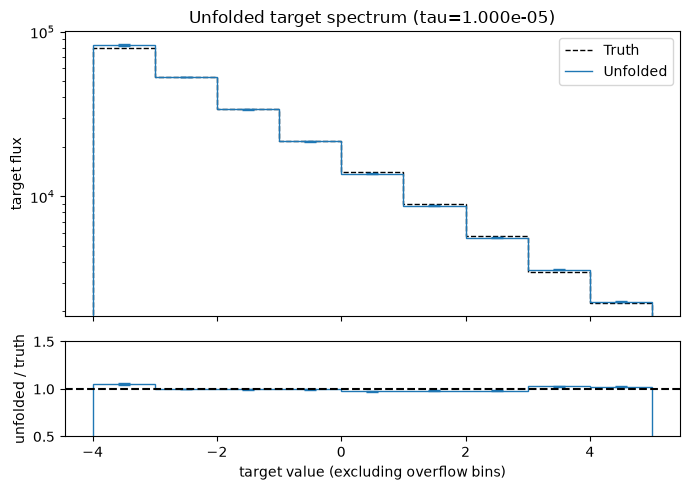

In [16]:
# select the best result based on the true error
best_result = results[results["rae"]==results["rae"].min()].iloc[0]
best_f_est, best_f_lower, best_f_upper, best_tau = best_result[[
    "f_est", "f_lower", "f_upper", "tau"]]

plot_result(best_f_est, best_f_lower, best_f_upper, best_tau)

Since we cannot assess the true error `rae` in a real analysis, we pick instead the result with the minimum global correlation coefficient, `gcc`. Among the criteria plotted above, this criterion produces the smallest error.

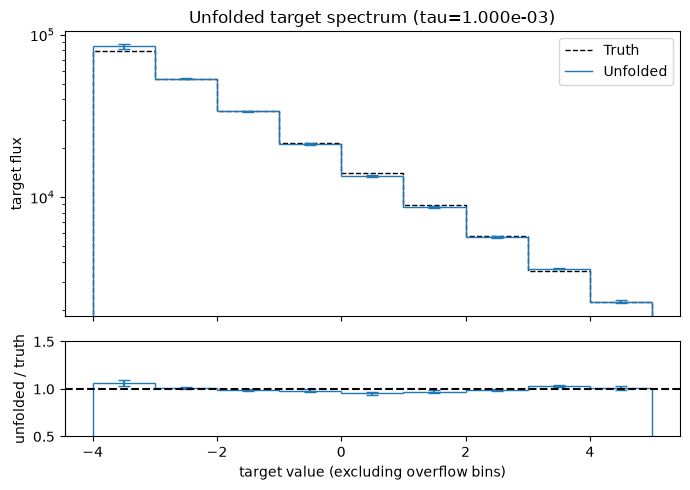

In [17]:
# select the best result based on the global correlation coefficient
selected_result = results[results["gcc"]==results["gcc"].min()].iloc[0]
selected_f_est, selected_f_lower, selected_f_upper, selected_tau = selected_result[[
    "f_est", "f_lower", "f_upper", "tau"]]

# plot the result; it's almost as good as the privileged solution above!
plot_result(selected_f_est, selected_f_lower, selected_f_upper, selected_tau)

## Limitations of this quickstart notebook

Throughout this notebook, we fitted a plain `caife.LinearCountModel`, which completely ignores the systematic parameter `S_trn` that `create_data` provides. In a real analysis, this would be a serious omission: if the true transfer behavior from target to proxy varies with an unmodeled systematic (as it does here, since `S` shapes the smearing that produces `X`), a systematics-unaware fit implicitly assumes one fixed transfer matrix `A`, which can both bias the unfolded spectrum and understate its uncertainty.

`caife` addresses systematics with the `caife.LinearSystematicsCountModel` (and `caife.MultiTargetSystematicsModel` for multi-dimensional targets), which fits a transfer matrix `A(s)` that varies with the systematic parameters and adds a corresponding latent component to `model.create_latents(...)`, so that unfolding jointly infers the target spectrum together with a plausible range of systematic values, instead of assuming they are already known. Redoing the steps above with `LinearSystematicsCountModel.fit(X_trn, y_trn, sample_weight=w_trn, systematics=S_trn)`, and comparing the result and its uncertainty to what we found here, is a natural next step beyond this quickstart.

This is one of several simplifications made here for clarity. We also never passed a `background` to `model.fit`.